# Problem 1
# Stock Trading game


In [ ]:
!pip install yfinance pandas numpy matplotlib backtrader ib_insync


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
# import yfinance as yf
import pandas as pd

# # Downloading AAPL data for the last 5 days at 1-minute intervals
# aapl_data = yf.download("AAPL", period="5d", interval="1m")
# aapl_data.to_csv("AAPL_data.csv")  # Save locally for later use
# aapl_data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2025-03-14 13:30:00+00:00,211.910004,212.259995,211.000000,211.250000,2556910
2025-03-14 13:31:00+00:00,212.419998,213.229996,211.910004,211.910004,491841
2025-03-14 13:32:00+00:00,212.445007,212.919998,212.149994,212.505005,392775
2025-03-14 13:33:00+00:00,213.149994,213.250000,212.440002,212.499893,408872
2025-03-14 13:34:00+00:00,213.399994,213.429993,212.979996,213.070099,356746


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving AAPL_data.csv to AAPL_data (1).csv


In [ ]:
data = pd.read_csv("AAPL_data.csv")
data

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Datetime,NaN,NaN,NaN,NaN,NaN
2,2025-03-14 13:30:00+00:00,211.91000366210938,212.25999450683594,211.0,211.25,2556910
3,2025-03-14 13:31:00+00:00,212.4199981689453,213.22999572753906,211.91000366210938,211.91000366210938,491841
4,2025-03-14 13:32:00+00:00,212.44500732421875,212.9199981689453,212.14999389648438,212.5050048828125,392775
...,...,...,...,...,...,...
1929,2025-03-20 19:55:00+00:00,214.42999267578125,214.75999450683594,213.72999572753906,213.72999572753906,562331
1930,2025-03-20 19:56:00+00:00,214.37130737304688,214.49000549316406,214.23500061035156,214.42999267578125,242853
1931,2025-03-20 19:57:00+00:00,214.4949951171875,214.52000427246094,214.33999633789062,214.38999938964844,344552
1932,2025-03-20 19:58:00+00:00,214.27999877929688,214.52999877929688,214.27000427246094,214.5,508729


In [ ]:
import pandas as pd

# Skip the first two rows, parse the first column as datetime (if it's the 0th column)
data = pd.read_csv("AAPL_data.csv", skiprows=2, parse_dates=[0], index_col=0)

# Inspect the first few rows
data


,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
Datetime,,,,,
2025-03-14 13:30:00+00:00,211.910004,212.259995,211.000000,211.250000,2556910
2025-03-14 13:31:00+00:00,212.419998,213.229996,211.910004,211.910004,491841
2025-03-14 13:32:00+00:00,212.445007,212.919998,212.149994,212.505005,392775
2025-03-14 13:33:00+00:00,213.149994,213.250000,212.440002,212.499893,408872
2025-03-14 13:34:00+00:00,213.399994,213.429993,212.979996,213.070099,356746
...,...,...,...,...,...
2025-03-20 19:55:00+00:00,214.429993,214.759995,213.729996,213.729996,562331
2025-03-20 19:56:00+00:00,214.371307,214.490005,214.235001,214.429993,242853
2025-03-20 19:57:00+00:00,214.494995,214.520004,214.339996,214.389999,344552


In [ ]:
# Check current columns
print(data.columns)

# Rename the columns
data.columns = ["Open", "High", "Low", "Close", "Volume"]

# Verify the change
data


Index(['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5'], dtype='object')


,Open,High,Low,Close,Volume
Datetime,,,,,
2025-03-14 13:30:00+00:00,211.910004,212.259995,211.000000,211.250000,2556910
2025-03-14 13:31:00+00:00,212.419998,213.229996,211.910004,211.910004,491841
2025-03-14 13:32:00+00:00,212.445007,212.919998,212.149994,212.505005,392775
2025-03-14 13:33:00+00:00,213.149994,213.250000,212.440002,212.499893,408872
2025-03-14 13:34:00+00:00,213.399994,213.429993,212.979996,213.070099,356746
...,...,...,...,...,...
2025-03-20 19:55:00+00:00,214.429993,214.759995,213.729996,213.729996,562331
2025-03-20 19:56:00+00:00,214.371307,214.490005,214.235001,214.429993,242853
2025-03-20 19:57:00+00:00,214.494995,214.520004,214.339996,214.389999,344552


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1932 entries, 2025-03-14 13:30:00+00:00 to 2025-03-20 19:59:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1932 non-null   float64
 1   High    1932 non-null   float64
 2   Low     1932 non-null   float64
 3   Close   1932 non-null   float64
 4   Volume  1932 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 90.6 KB


In [ ]:
# Quick check: Ensure index is a DatetimeIndex
print(type(data.index))
# Should be: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

# Optional deeper check for any non-datetime values
for idx in data.index:
    if not isinstance(idx, pd.Timestamp):
        print("Found non-datetime:", idx, type(idx))


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
data

,Open,High,Low,Close,Volume
Datetime,,,,,
2025-03-14 13:30:00+00:00,211.910004,212.259995,211.000000,211.250000,2556910
2025-03-14 13:31:00+00:00,212.419998,213.229996,211.910004,211.910004,491841
2025-03-14 13:32:00+00:00,212.445007,212.919998,212.149994,212.505005,392775
2025-03-14 13:33:00+00:00,213.149994,213.250000,212.440002,212.499893,408872
2025-03-14 13:34:00+00:00,213.399994,213.429993,212.979996,213.070099,356746
...,...,...,...,...,...
2025-03-20 19:55:00+00:00,214.429993,214.759995,213.729996,213.729996,562331
2025-03-20 19:56:00+00:00,214.371307,214.490005,214.235001,214.429993,242853
2025-03-20 19:57:00+00:00,214.494995,214.520004,214.339996,214.389999,344552


In [ ]:
print(type(data.index))
# Should be <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
print(data.index.nlevels)
# Should be 1 if you have a single-level DatetimeIndex


1


In [ ]:
print(data.head(10))
print(data.tail(10))


                                 Open        High         Low       Close  \
Datetime                                                                    
2025-03-14 13:30:00+00:00  211.910004  212.259995  211.000000  211.250000   
2025-03-14 13:31:00+00:00  212.419998  213.229996  211.910004  211.910004   
2025-03-14 13:32:00+00:00  212.445007  212.919998  212.149994  212.505005   
2025-03-14 13:33:00+00:00  213.149994  213.250000  212.440002  212.499893   
2025-03-14 13:34:00+00:00  213.399994  213.429993  212.979996  213.070099   
2025-03-14 13:35:00+00:00  213.134995  213.422806  212.701096  213.399994   
2025-03-14 13:36:00+00:00  212.764999  213.210007  212.492996  213.130005   
2025-03-14 13:37:00+00:00  212.869995  213.044998  212.630005  212.764999   
2025-03-14 13:38:00+00:00  212.600006  212.949997  212.424606  212.880005   
2025-03-14 13:39:00+00:00  212.689301  213.050003  212.529999  212.608795   

                            Volume  
Datetime                            
2

In [ ]:
duplicates = data.index.duplicated(keep=False)
print(data[duplicates])


Empty DataFrame
Columns: [Open, High, Low, Close, Volume]
Index: []


In [ ]:
data.index = data.index.tz_convert('UTC')


In [ ]:
print(data.index.tz)

UTC


In [ ]:
# 1) Ensure the index is fully in UTC
data.index = data.index.tz_convert('UTC')

# 2) Remove (localize to None) the timezone so it's a naive DatetimeIndex
data.index = data.index.tz_localize(None)

# Now check the index
print(data.index.dtype)
# Should show something like: datetime64[ns]


datetime64[ns]


In [ ]:
data

,Open,High,Low,Close,Volume
Datetime,,,,,
2025-03-14 13:30:00,211.910004,212.259995,211.000000,211.250000,2556910
2025-03-14 13:31:00,212.419998,213.229996,211.910004,211.910004,491841
2025-03-14 13:32:00,212.445007,212.919998,212.149994,212.505005,392775
2025-03-14 13:33:00,213.149994,213.250000,212.440002,212.499893,408872
2025-03-14 13:34:00,213.399994,213.429993,212.979996,213.070099,356746
...,...,...,...,...,...
2025-03-20 19:55:00,214.429993,214.759995,213.729996,213.729996,562331
2025-03-20 19:56:00,214.371307,214.490005,214.235001,214.429993,242853
2025-03-20 19:57:00,214.494995,214.520004,214.339996,214.389999,344552


In [ ]:
# data_feed = bt.feeds.PandasData(dataname=data)
# cerebro = bt.Cerebro()
# cerebro.adddata(data_feed)
# cerebro.addstrategy(AdvancedSmaCrossover)
# cerebro.run()


Closed: Gross PnL: -0.7649993896484659, Net PnL: -0.7649993896484659
Closed: Gross PnL: 1.060012817382841, Net PnL: 1.060012817382841
Closed: Gross PnL: -0.4149932861328409, Net PnL: -0.4149932861328409
Closed: Gross PnL: 0.8199920654296875, Net PnL: 0.8199920654296875
Closed: Gross PnL: -0.22930908203122158, Net PnL: -0.22930908203122158
Closed: Gross PnL: 0.5711975097656534, Net PnL: 0.5711975097656534
Closed: Gross PnL: -0.11489868164059658, Net PnL: -0.11489868164059658
Closed: Gross PnL: 0.014587402343778422, Net PnL: 0.014587402343778422
Closed: Gross PnL: -1.0, Net PnL: -1.0
Closed: Gross PnL: 1.535003662109375, Net PnL: 1.535003662109375
Closed: Gross PnL: -0.247894287109375, Net PnL: -0.247894287109375
Closed: Gross PnL: 0.22169494628903408, Net PnL: 0.22169494628903408
Closed: Gross PnL: -0.26979064941411934, Net PnL: -0.26979064941411934
Closed: Gross PnL: -0.19509887695315342, Net PnL: -0.19509887695315342
Closed: Gross PnL: 0.7371063232421875, Net PnL: 0.7371063232421875
C

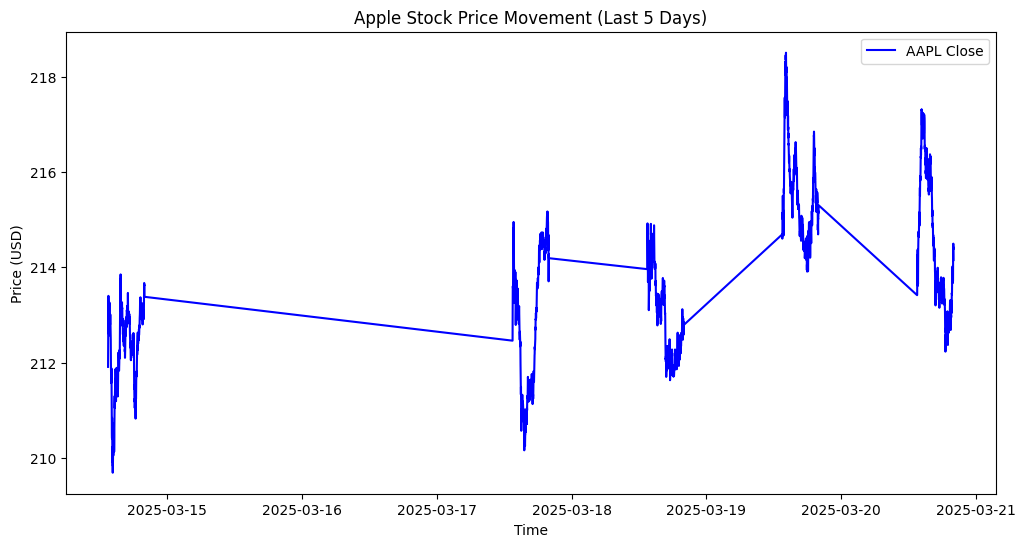

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(aapl_data.index, aapl_data['Close'], label="AAPL Close", color='blue')
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.title("Apple Stock Price Movement (Last 5 Days)")
plt.legend()
plt.show()


In [ ]:
import backtrader as bt

class AdvancedSmaCrossover(bt.Strategy):
    """
    A more advanced strategy that:
    - Buys when Short SMA crosses above Long SMA
    - Sells when Short SMA crosses below Long SMA
    - Applies a stop-loss and take-profit
    """

    params = (
        ('pfast', 5),       # Short SMA period
        ('pslow', 20),      # Long SMA period
        ('stop_loss', 0.02),  # 2% stop-loss
        ('take_profit', 0.04) # 4% take-profit
    )

    def __init__(self):
        # Initialize short and long SMAs
        self.sma_short = bt.indicators.SimpleMovingAverage(
            self.data.close, period=self.p.pfast)
        self.sma_long = bt.indicators.SimpleMovingAverage(
            self.data.close, period=self.p.pslow)

        # Crossover signal
        self.crossover = bt.indicators.CrossOver(self.sma_short, self.sma_long)

        # Track entry price to apply stop-loss & take-profit
        self.entry_price = None

    def next(self):
        # If we are not in a position
        if not self.position:
            # Check for BUY signal
            if self.crossover > 0:  # short SMA crosses above long SMA
                self.buy()
                self.entry_price = self.data.close[0]
        else:
            # If we are in a position, check exit conditions

            # 1) Stop-Loss
            if self.data.close[0] <= self.entry_price * (1 - self.p.stop_loss):
                self.close()

            # 2) Take-Profit
            elif self.data.close[0] >= self.entry_price * (1 + self.p.take_profit):
                self.close()

            # 3) If crossover < 0 => short SMA below long SMA => exit
            elif self.crossover < 0:
                self.close()

    def notify_trade(self, trade):
        """Optional: Log trade details."""
        if trade.isclosed:
            print(f'Closed: Gross PnL: {trade.pnl}, Net PnL: {trade.pnlcomm}')

    def stop(self):
        """Log final portfolio value or other metrics."""
        print(f'(pfast={self.p.pfast}, pslow={self.p.pslow}) Final Value: {self.broker.getvalue():.2f}')


In [ ]:
import backtrader.analyzers as btanalyzers

cerebro = bt.Cerebro()
cerebro.adddata(data_feed)
cerebro.addstrategy(AdvancedSmaCrossover)

# Add analyzers
cerebro.addanalyzer(btanalyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(btanalyzers.DrawDown, _name='drawdown')

results = cerebro.run()
strat = results[0]

# Extract analyzers
sharpe_analyzer = strat.analyzers.sharpe.get_analysis()
drawdown_analyzer = strat.analyzers.drawdown.get_analysis()

print("Sharpe Ratio:", sharpe_analyzer['sharperatio'])
print("Drawdown Analyzer Output:", drawdown_analyzer)
print("Max Drawdown (%):", drawdown_analyzer.get('maxdrawdown', 'N/A'))
print("Drawdown Money:", drawdown_analyzer.get('maxmoneydown', 'N/A'))



Closed: Gross PnL: -0.7649993896484659, Net PnL: -0.7649993896484659
Closed: Gross PnL: 1.060012817382841, Net PnL: 1.060012817382841
Closed: Gross PnL: -0.4149932861328409, Net PnL: -0.4149932861328409
Closed: Gross PnL: 0.8199920654296875, Net PnL: 0.8199920654296875
Closed: Gross PnL: -0.22930908203122158, Net PnL: -0.22930908203122158
Closed: Gross PnL: 0.5711975097656534, Net PnL: 0.5711975097656534
Closed: Gross PnL: -0.11489868164059658, Net PnL: -0.11489868164059658
Closed: Gross PnL: 0.014587402343778422, Net PnL: 0.014587402343778422
Closed: Gross PnL: -1.0, Net PnL: -1.0
Closed: Gross PnL: 1.535003662109375, Net PnL: 1.535003662109375
Closed: Gross PnL: -0.247894287109375, Net PnL: -0.247894287109375
Closed: Gross PnL: 0.22169494628903408, Net PnL: 0.22169494628903408
Closed: Gross PnL: -0.26979064941411934, Net PnL: -0.26979064941411934
Closed: Gross PnL: -0.19509887695315342, Net PnL: -0.19509887695315342
Closed: Gross PnL: 0.7371063232421875, Net PnL: 0.7371063232421875
C

# Risk Management

In [ ]:
import backtrader as bt

class RiskManagementSizer(bt.Sizer):
    params = (
        ('risk', 0.01),         # risk per trade as a fraction of account equity (1%)
        ('stop_loss_pct', 0.02),  # stop loss percentage (2%)
    )

    def _getsizing(self, comminfo, cash, data, isbuy):
        if isbuy:
            # Current price from the data feed
            price = data.close[0]
            # Amount of money you are willing to risk per trade
            risk_amount = self.p.risk * cash
            # Risk per share: the amount lost per share if stop loss is hit
            risk_per_share = price * self.p.stop_loss_pct
            if risk_per_share == 0:
                return 0
            # Calculate number of shares: risk_amount divided by risk per share
            size = risk_amount / risk_per_share
            # Return an integer number of shares
            return int(size)
        else:
            return 0


In [ ]:
class AdvancedSmaCrossover(bt.Strategy):
    params = (
        ('pfast', 5),       # Short SMA period
        ('pslow', 20),      # Long SMA period
        ('stop_loss', 0.02),  # 2% stop-loss (used inside the strategy)
        ('take_profit', 0.04) # 4% take-profit
    )

    def __init__(self):
        self.sma_short = bt.indicators.SimpleMovingAverage(self.data.close, period=self.p.pfast)
        self.sma_long = bt.indicators.SimpleMovingAverage(self.data.close, period=self.p.pslow)
        self.crossover = bt.indicators.CrossOver(self.sma_short, self.sma_long)
        self.entry_price = None

    def next(self):
        if not self.position:
            if self.crossover > 0:  # Buy signal
                self.buy()  # The sizer will determine the number of shares to buy
                self.entry_price = self.data.close[0]
        else:
            # Stop-loss: if the current price drops below the entry by more than stop_loss
            if self.data.close[0] <= self.entry_price * (1 - self.p.stop_loss):
                self.close()
            # Take-profit: if the price rises enough above the entry
            elif self.data.close[0] >= self.entry_price * (1 + self.p.take_profit):
                self.close()
            # Also exit if the crossover signal reverses
            elif self.crossover < 0:
                self.close()

    def notify_trade(self, trade):
        if trade.isclosed:
            print(f'Closed: Gross PnL: {trade.pnl}, Net PnL: {trade.pnlcomm}')

    def stop(self):
        print(f'(pfast={self.p.pfast}, pslow={self.p.pslow}) Final Value: {self.broker.getvalue():.2f}')


In [ ]:
import backtrader.analyzers as btanalyzers

cerebro = bt.Cerebro()

# Add your data feed (assuming 'data' is your cleaned DataFrame and data_feed is defined)
cerebro.adddata(data_feed)

# Add your advanced strategy
cerebro.addstrategy(AdvancedSmaCrossover)

# Attach the custom sizer: use risk 1% and stop_loss_pct 2%
cerebro.addsizer(RiskManagementSizer, risk=0.01, stop_loss_pct=0.02)

# Set initial capital
cerebro.broker.setcash(100000.0)

# Set a commission (optional)
cerebro.broker.setcommission(commission=0.001)

# Add analyzers (if you want to see performance metrics)
cerebro.addanalyzer(btanalyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(btanalyzers.DrawDown, _name='drawdown')

# Run the backtest
results = cerebro.run()
strat = results[0]

# Access analyzers (using .get() for safety)
sharpe_analyzer = strat.analyzers.sharpe.get_analysis()
drawdown_analyzer = strat.analyzers.drawdown.get_analysis()

print("Final Portfolio Value:", cerebro.broker.getvalue())
print("Sharpe Ratio:", sharpe_analyzer.get('sharperatio', 'N/A'))
print("Drawdown Analyzer Output:", drawdown_analyzer)
print("Max Drawdown (%):", drawdown_analyzer.get('max', {}).get('drawdown', 'N/A'))
print("Max Drawdown Money:", drawdown_analyzer.get('max', {}).get('moneydown', 'N/A'))

# Plot the results
cerebro.plot()


Closed: Gross PnL: -179.00985717774103, Net PnL: -278.42124874878596
Closed: Gross PnL: 250.16302490235046, Net PnL: 150.47190533447935
Closed: Gross PnL: -97.52342224121762, Net PnL: -197.00009910584166
Closed: Gross PnL: 191.87814331054688, Net PnL: 92.37198202514648
Closed: Gross PnL: -53.65832519530585, Net PnL: -153.0359500122004
Closed: Gross PnL: 133.6602172851629, Net PnL: 33.894037353522265
Closed: Gross PnL: -26.771392822259003, Net PnL: -126.04922427367501
Closed: Gross PnL: 3.4134521484441507, Net PnL: -95.88809838866524
Closed: Gross PnL: -234.0, Net PnL: -333.19259857177735
Closed: Gross PnL: 359.19085693359375, Net PnL: 259.7841463623047
Closed: Gross PnL: -57.759368896484375, Net PnL: -156.98192968749998
Closed: Gross PnL: 51.433227539055906, Net PnL: -47.49117810059252
Closed: Gross PnL: -62.59143066407569, Net PnL: -161.68563781739599
Closed: Gross PnL: -45.6531372070379, Net PnL: -144.4444480590887
Closed: Gross PnL: 172.48287963867188, Net PnL: 73.7763230895996
Clos

<IPython.core.display.Javascript object>

[[<Figure size 640x480 with 5 Axes>]]

In [ ]:
import backtrader as bt
import backtrader.analyzers as btanalyzers
import pandas as pd

# Assume 'data' is your cleaned DataFrame with a proper DatetimeIndex
# and that you have already set it up appropriately.
# For example:
print("Backtest period:")
print("Start:", data.index.min())
print("End:  ", data.index.max())

# Create your data feed from your DataFrame
data_feed = bt.feeds.PandasData(dataname=data)

# Initialize Cerebro engine
cerebro = bt.Cerebro()
cerebro.adddata(data_feed)

# Add your strategy (AdvancedSmaCrossover as defined previously)
cerebro.addstrategy(AdvancedSmaCrossover)

# Attach analyzers for performance metrics and trade statistics
cerebro.addanalyzer(btanalyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(btanalyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(btanalyzers.TradeAnalyzer, _name='tradeanalyzer')

# Set initial cash
cerebro.broker.setcash(100000.0)

# Set commission
cerebro.broker.setcommission(commission=0.001)

# Run the backtest
results = cerebro.run()
strat = results[0]

# Extract analyzers
sharpe_analyzer = strat.analyzers.sharpe.get_analysis()
drawdown_analyzer = strat.analyzers.drawdown.get_analysis()
trade_analyzer = strat.analyzers.tradeanalyzer.get_analysis()

# Print performance metrics
print("Final Portfolio Value:", cerebro.broker.getvalue())
print("Sharpe Ratio:", sharpe_analyzer.get('sharperatio', 'N/A'))
print("Drawdown Analyzer Output:", drawdown_analyzer)
print("Max Drawdown (%):", drawdown_analyzer.get('max', {}).get('drawdown', 'N/A'))
print("Max Drawdown Money:", drawdown_analyzer.get('max', {}).get('moneydown', 'N/A'))

# Print trade analyzer details
if 'closed' in trade_analyzer and 'total' in trade_analyzer['closed']:
    print("Total Closed Trades:", trade_analyzer['closed']['total'])
else:
    print("Trade Analyzer Data:", trade_analyzer)

# Additionally, if you want to see the trade details:
print("Full Trade Analyzer Output:", trade_analyzer)

# Plot the strategy results
cerebro.plot()


Backtest period:
Start: 2025-03-14 13:30:00
End:   2025-03-20 19:59:00
Closed: Gross PnL: -0.7649993896484659, Net PnL: -1.189834396362333
Closed: Gross PnL: 1.060012817382841, Net PnL: 0.6375928192138955
Closed: Gross PnL: -0.4149932861328409, Net PnL: -0.8382982940674113
Closed: Gross PnL: 0.8199920654296875, Net PnL: 0.3947520599365234
Closed: Gross PnL: -0.22930908203122158, Net PnL: -0.6539997863769247
Closed: Gross PnL: 0.5711975097656534, Net PnL: 0.14484631347659088
Closed: Gross PnL: -0.11489868164059658, Net PnL: -0.5409837951659872
Closed: Gross PnL: 0.014587402343778422, Net PnL: -0.4097781982421591
Closed: Gross PnL: -1.0, Net PnL: -1.4238999938964843
Closed: Gross PnL: 1.535003662109375, Net PnL: 1.1101886596679686
Closed: Gross PnL: -0.247894287109375, Net PnL: -0.6737421875
Closed: Gross PnL: 0.22169494628903408, Net PnL: -0.20470335388186434
Closed: Gross PnL: -0.26979064941411934, Net PnL: -0.6969208526611896
Closed: Gross PnL: -0.19509887695315342, Net PnL: -0.617283

[[<Figure size 640x480 with 10 Axes>]]

#Strategy Optimization

In [ ]:
import backtrader as bt
import backtrader.analyzers as btanalyzers

# Assume data_feed is already created from your cleaned DataFrame
# e.g., data_feed = bt.feeds.PandasData(dataname=data)

# --- Step 1: Set Up Cerebro for Optimization ---
cerebro = bt.Cerebro()
cerebro.adddata(data_feed)

# Use a narrow parameter range for demonstration (only one combination)
cerebro.optstrategy(
    AdvancedSmaCrossover,
    pfast=[10],   # Using a fixed value to help extraction
    pslow=[30]
)

# Set broker settings
cerebro.broker.setcash(100000.0)
cerebro.broker.setcommission(commission=0.001)

# Add analyzers
cerebro.addanalyzer(btanalyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(btanalyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(btanalyzers.TradeAnalyzer, _name='tradeanalyzer')

# Run the optimization
optimized_runs = cerebro.run(maxcpus=1)
print("Raw Optimization Results:")
print(optimized_runs)

# --- Step 2: Extract Best Strategy Instance ---
best_final_value = -float('inf')
best_params = None

# Try to extract the strategy instance from each optimization result
for run in optimized_runs:
    for opt in run:
        strat_instance = None
        if hasattr(opt, 'broker'):
            strat_instance = opt
        elif hasattr(opt, 'strats'):
            # Some OptReturn objects store strategies in 'strats'
            strat_instance = opt.strats[0]
        else:
            try:
                strat_instance = opt[0]
            except Exception as e:
                print("Error extracting strategy instance:", e)
                continue

        # If extraction failed, continue
        if strat_instance is None:
            continue

        # Try to access the broker value
        try:
            final_value = strat_instance.broker.getvalue()
        except Exception as e:
            print("Error accessing broker value:", e)
            continue

        pfast = strat_instance.params.pfast
        pslow = strat_instance.params.pslow
        print(f"pfast={pfast}, pslow={pslow} -> Final Value: {final_value:.2f}")

        # Update best parameters if needed
        if final_value > best_final_value:
            best_final_value = final_value
            best_params = (pfast, pslow)

# --- Step 3: Fallback if No Valid Strategy Instance Found ---
if best_params is None:
    print("No valid strategy instance found in optimization results. Running a fallback non-optimization run.")
    cerebro = bt.Cerebro()
    cerebro.adddata(data_feed)
    cerebro.addstrategy(AdvancedSmaCrossover, pfast=10, pslow=30)
    cerebro.broker.setcash(100000.0)
    cerebro.broker.setcommission(commission=0.001)
    results = cerebro.run()
    strat = results[0]
    best_final_value = strat.broker.getvalue()
    best_params = (strat.params.pfast, strat.params.pslow)
    print(f"Fallback run: pfast={best_params[0]}, pslow={best_params[1]} -> Final Value: {best_final_value:.2f}")
else:
    print("\nBest Parameters Based on Final Portfolio Value:")
    print(f"pfast = {best_params[0]}, pslow = {best_params[1]}, Final Value: {best_final_value:.2f}")


Closed: Gross PnL: 1.109710693359375, Net PnL: 0.68702099609375
Closed: Gross PnL: 0.7308044433593466, Net PnL: 0.30569363403317473
Closed: Gross PnL: -0.09999084472659092, Net PnL: -0.5257908477783487
Closed: Gross PnL: -0.9799957275390909, Net PnL: -1.4040157318115518
Closed: Gross PnL: 1.226608276367216, Net PnL: 0.801821670532255
Closed: Gross PnL: 0.19499206542971592, Net PnL: -0.23236293029782318
Closed: Gross PnL: -0.220001220703125, Net PnL: -0.6463812255859375
Closed: Gross PnL: 0.029998779296875, Net PnL: -0.39603121948242187
Closed: Gross PnL: 0.44720458984375, Net PnL: 0.024897399902343742
Closed: Gross PnL: -0.2899932861328409, Net PnL: -0.7128832855224894
Closed: Gross PnL: 3.0450134277343466, Net PnL: 2.6186084289550497
Closed: Gross PnL: -0.113494873046875, Net PnL: -0.5427213745117188
Closed: Gross PnL: -1.080307006835909, Net PnL: -1.5087967071532917
Closed: Gross PnL: 0.02101135253909092, Net PnL: -0.40710844421383885
Closed: Gross PnL: -0.584991455078125, Net PnL: -

In [ ]:
import backtrader as bt
import backtrader.analyzers as btanalyzers

# --- Set up Cerebro for Optimization ---
# Use optreturn=False so that optimization returns actual strategy instances.
cerebro = bt.Cerebro(optreturn=False)

# Add your data feed (make sure data_feed is defined)
cerebro.adddata(data_feed)

# Define the optimization ranges for pfast and pslow.
cerebro.optstrategy(
    AdvancedSmaCrossover,
    pfast=range(5, 11),        # 5,6,7,8,9,10
    pslow=range(15, 31, 5)      # 15,20,25,30
)

# Set initial cash and commission
cerebro.broker.setcash(100000.0)
cerebro.broker.setcommission(commission=0.001)

# Add analyzers for performance metrics
cerebro.addanalyzer(btanalyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(btanalyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(btanalyzers.TradeAnalyzer, _name='tradeanalyzer')

# --- Run the Optimization ---
optimized_runs = cerebro.run(maxcpus=1, optreturn=False)

# --- Process the Optimization Results ---
best_final_value = -float('inf')
best_params = None

print("Optimization Results:")
# optimized_runs is now a list of lists of strategy instances.
for run in optimized_runs:
    for strat in run:
        final_value = strat.broker.getvalue()
        pfast = strat.params.pfast
        pslow = strat.params.pslow
        sharpe = strat.analyzers.sharpe.get_analysis().get('sharperatio', None)
        drawdown = strat.analyzers.drawdown.get_analysis().get('max', {}).get('drawdown', None)

        print(f"pfast={pfast}, pslow={pslow} -> Final Value: {final_value:.2f}, "
              f"Sharpe Ratio: {sharpe}, Max Drawdown: {drawdown}")

        if final_value > best_final_value:
            best_final_value = final_value
            best_params = (pfast, pslow)

# --- Report the Best Parameters ---
print("\nBest Parameters Based on Final Portfolio Value:")
if best_params is not None:
    print(f"pfast = {best_params[0]}, pslow = {best_params[1]}, Final Value: {best_final_value:.2f}")
else:
    print("No valid strategy instance found.")


Closed: Gross PnL: -0.0999908447265625, Net PnL: -0.5250708465576173
Closed: Gross PnL: 0.6799926757812784, Net PnL: 0.25787268066409086
Closed: Gross PnL: -0.15499877929684658, Net PnL: -0.5782937927245809
Closed: Gross PnL: 0.05018615722653408, Net PnL: -0.3742840423584268
Closed: Gross PnL: 0.8950042724609091, Net PnL: 0.4698392791747762
Closed: Gross PnL: -0.2699890136719034, Net PnL: -0.6959590148926065
Closed: Gross PnL: -0.360198974609375, Net PnL: -0.7851191711425781
Closed: Gross PnL: 0.3000030517578125, Net PnL: -0.1260769500732422
Closed: Gross PnL: -0.065399169921875, Net PnL: -0.4914347839355469
Closed: Gross PnL: 0.02499389648434658, Net PnL: -0.39944110107424713
Closed: Gross PnL: -0.785003662109375, Net PnL: -1.20911865234375
Closed: Gross PnL: 1.410003662109375, Net PnL: 0.9853136596679688
Closed: Gross PnL: -0.23500061035153408, Net PnL: -0.6608356170654013
Closed: Gross PnL: 0.6649932861328409, Net PnL: 0.23850828552248937
Closed: Gross PnL: -1.0700073242187784, Net 

# Trading account alpaca

In [2]:
!pip install alpaca-trade-api


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.7/757.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 7.2 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.3-cp311-cp311-linux_x86_64.whl size=15688 sha256=47dd26651e6611f20f7efd1b84973a4f2de497676f0f0ddb665a1064da9e1519
  Stored in directory: /root/.cache/pip/wheels/f6/35/da/ed9b26b510235e00e3a3c3bab7bad97b59214729662255ab3d
Successfully built msgpack
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.1.0
    Uninstalling msgpack-1.1.0:
      Successfully uninstalled msgpack-1.1.0
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling

In [3]:
import alpaca_trade_api as tradeapi

# Replace these with your Alpaca paper trading API credentials
API_KEY = "PK1OUSAISR43CX8VCP0V"
API_SECRET = "JCGH3wm3wxpTwKO49zXYJV3s1YjzpZPA8hmQC3rh"
BASE_URL = "https://paper-api.alpaca.markets"  # Alpaca paper trading endpoint

# Connect to the Alpaca REST API
api = tradeapi.REST(API_KEY, API_SECRET, BASE_URL, api_version='v2')

# Get account information
account = api.get_account()
print("Account Status:", account.status)
print("Buying Power:", account.buying_power)


Account Status: ACTIVE
Buying Power: 200000


In [13]:
import alpaca_trade_api as tradeapi
import time
import datetime

# Replace these with your Alpaca paper trading API credentials
API_KEY = "PK1OUSAISR43CX8VCP0V"
API_SECRET = "JCGH3wm3wxpTwKO49zXYJV3s1YjzpZPA8hmQC3rh"
BASE_URL = "https://paper-api.alpaca.markets"

# Initialize the Alpaca REST API (v2)
api = tradeapi.REST(API_KEY, API_SECRET, BASE_URL, api_version='v2')

def get_latest_bar(symbol):
    """
    Retrieve the latest 1-minute bar for the given symbol.
    Note: We subtract 15 minutes from UTC time to access delayed data available in a free account.
    """
    # Adjust for data delay: use data at least 15 minutes old
    now = datetime.datetime.utcnow() - datetime.timedelta(minutes=15)
    start_dt = now - datetime.timedelta(minutes=1)
    start_str = start_dt.isoformat(timespec='seconds') + 'Z'
    end_str = now.isoformat(timespec='seconds') + 'Z'

    try:
        bars = api.get_bars(symbol, tradeapi.TimeFrame.Minute, start=start_str, end=end_str, limit=1).df
        if bars.empty:
            return None
        # Return the most recent bar (row) from the DataFrame
        return bars.iloc[-1]
    except Exception as e:
        print("Error retrieving bar:", e)
        return None

def generate_signal(bar):
    """
    Dummy signal generator.
    Replace this with your actual trading logic.
    For example: if the closing price is above a threshold, signal 'buy'; below, signal 'sell'; else, 'hold'.
    """
    if bar['close'] > 220.75:
        return 'buy'
    elif bar['close'] < 220.73:
        return 'sell'
    else:
        return 'hold'

def execute_trade(symbol, signal, qty=1):
    """
    Execute a trade based on the given signal.
    """
    try:
        if signal == 'buy':
            order = api.submit_order(
                symbol=symbol,
                qty=qty,
                side='buy',
                type='market',
                time_in_force='gtc'  # Good 'til canceled
            )
            print(f"Submitted BUY order for {qty} share(s) of {symbol}.")
        elif signal == 'sell':
            order = api.submit_order(
                symbol=symbol,
                qty=qty,
                side='sell',
                type='market',
                time_in_force='gtc'
            )
            print(f"Submitted SELL order for {qty} share(s) of {symbol}.")
        else:
            print("Hold signal. No order executed.")
    except Exception as e:
        print("Error executing trade:", e)

# Main loop for paper trading
symbol = 'AAPL'
print("Starting paper trading loop for", symbol)
while True:
    bar = get_latest_bar(symbol)
    if bar is not None:
        # Print the latest bar details
        print(f"Latest bar at {bar.name}: Close = {bar['close']}")
        # Generate a signal based on the bar
        signal = generate_signal(bar)
        print("Trading Signal:", signal)
        # Execute the trade based on the signal
        execute_trade(symbol, signal, qty=1)
    else:
        print("No bar data available.")

    # Wait for a minute before checking for new data
    time.sleep(60)


Starting paper trading loop for AAPL
No bar data available.
Latest bar at 2025-03-24 22:46:00+00:00: Close = 220.72
Trading Signal: sell
Error executing trade: potential wash trade detected. use complex orders
No bar data available.
Latest bar at 2025-03-24 22:48:00+00:00: Close = 220.71
Trading Signal: sell
Error executing trade: potential wash trade detected. use complex orders
No bar data available.
Latest bar at 2025-03-24 22:50:00+00:00: Close = 220.71
Trading Signal: sell
Error executing trade: potential wash trade detected. use complex orders
Latest bar at 2025-03-24 22:51:00+00:00: Close = 220.71
Trading Signal: sell
Error executing trade: potential wash trade detected. use complex orders
No bar data available.
No bar data available.


KeyboardInterrupt: 